# 数据整合-锚定点


In [3]:
##系统报错改为英文
Sys.setenv(LANGUAGE = "en")
##禁止转化为因子
options(stringsAsFactors = FALSE)
##清空环境
rm(list=ls())

setwd("/Users/a1-6/Documents/projects/DL/97-bioinformatics/gene_process_for_python/single-cell-rna")
###加载所需要的包
library(Seurat)
library(tidyverse)
library(dplyr)
library(patchwork)

x=list.files()
x


[1] "01-\345\215\225\347\273\206\350\203\236\346\225\260\346\215\256\350\257\264\346\230\216.ipynb"                                    
[2] "02-SCTransfom\345\216\273\346\211\271\346\254\241\346\225\210\345\272\224.ipynb"                                                  
[3] "03-\351\224\232\345\256\232\346\263\225\345\257\271\351\241\271\347\233\256\346\225\260\346\215\256\346\225\264\345\220\210.ipynb"
[4] "04-harmony\345\257\271\351\241\271\347\233\256\346\225\260\346\215\256\347\235\200\346\225\264\345\220\210.ipynb"                 
[5] "README.md"                                                                                                                        
[6] "data"                                                                                                                             
[7] "results"                                                                                                                          
[8] "scrna01.R"

In [6]:
getwd()

[1] "/Users/a1-6/Documents/projects/DL/97-bioinformatics/gene_process_for_python/single-cell-rna"

In [ ]:
### 一步读取
dir = c('data/GSE152048/BC2/', "data/GSE152048/BC21/")
names(dir) = c('BC2',  'BC21')  
counts <- Read10X(data.dir =dir)
scRNA1 = CreateSeuratObject(counts,min.cells = 3, min.features = 200)
table(scRNA1@meta.data$orig.ident)
dir[1]


 BC2 BC21 
5960 6497 

BC2 
"data/GSE152048/BC2/"

In [9]:
str(scRNA1)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. .. .. ..@ layers    :List of 1
  .. .. .. .. ..$ counts:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:19616843] 48 74 103 138 213 269 309 320 329 373 ...
  .. .. .. .. .. .. ..@ p       : int [1:12458] 0 620 1291 1741 2529 3139 3613 4151 4568 5088 ...
  .. .. .. .. .. .. ..@ Dim     : int [1:2] 21055 12457
  .. .. .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. ..@ x       : num [1:19616843] 1 1 1 1 1 1 1 3 1 3 ...
  .. .. .. .. .. .. ..@ factors : list()
  .. .. .. ..@ cells     :Formal class 'LogMap' [package "SeuratObject"] with 1 slot
  .. .. .. .. .. ..@ .Data: logi [1:12457, 1] TRUE TRUE TRUE TRUE TRUE TRUE ...
  .. .. .. .. .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. .. .. .. .. ..$

In [8]:
scRNA1

An object of class Seurat 
21055 features across 12457 samples within 1 assay 
Active assay: RNA (21055 features, 0 variable features)
 1 layer present: counts

In [ ]:
### 分布步读取（推荐）
scRNAlist <- list()
for(i in 1:length(dir)){
  counts <- Read10X(data.dir = dir[i])
  scRNAlist[[i]] <- CreateSeuratObject(counts, min.cells = 3, min.features =300)
}

scRNAlist

[[1]]
An object of class Seurat 
16647 features across 5937 samples within 1 assay 
Active assay: RNA (16647 features, 0 variable features)
 1 layer present: counts

[[2]]
An object of class Seurat 
20288 features across 6342 samples within 1 assay 
Active assay: RNA (20288 features, 0 variable features)
 1 layer present: counts


In [12]:
for (i in 1:length(scRNAlist)) {
  scRNAlist[[i]] <- NormalizeData(scRNAlist[[i]])
  scRNAlist[[i]] <- FindVariableFeatures(scRNAlist[[i]], selection.method = "vst",nfeatures = 3000)
}

Normalizing layer: counts



Finding variable features for layer counts

Normalizing layer: counts

Finding variable features for layer counts



In [22]:
colnames(scRNA1@meta.data)

[1] "orig.ident"   "nCount_RNA"   "nFeature_RNA"

In [24]:
#### 开始整合
library(future)
plan(multisession, workers = 1)
options(future.globals.maxSize = 2000 * 1024^2)

###
## 需要传 list ,使用方法1 读取需要切割
colnames(scRNA1@meta.data)
sc.list = SplitObject(scRNA1, split.by = 'orig.ident')
###
### 选择基因特征
features <- SelectIntegrationFeatures(object.list = scRNAlist)



[1] "orig.ident"   "nCount_RNA"   "nFeature_RNA"

In [25]:
#### 需要锚定的对象
scRNA.anchors <- FindIntegrationAnchors(object.list = scRNAlist, 
                                        anchor.features = features)

#### 开始整合
scRNA1 <- IntegrateData(anchorset = scRNA.anchors)

Scaling features for provided objects

Finding all pairwise anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 9154 anchors

Filtering anchors

	Retained 4207 anchors

Merging dataset 1 into 2

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data

Warning message:
"Layer counts isn't present in the assay object; returning NULL"


In [26]:
### 激活默认的层，原始是“RNA”
DefaultAssay(scRNA1) <- "integrated"

scRNA1=ScaleData(scRNA1)

scRNA1 <- RunPCA(scRNA1, npcs = 30, verbose = T)

Centering and scaling data matrix

PC_ 1 
Positive:  RGS10, HLA-DRB1, CD68, MMP9, HLA-DQA1, CD84, RAC2, CHCHD10, HLA-DPA1, HLA-DRA 
	   ACP5, MATK, ATP6V1B2, HSPA8, TCIRG1, LYZ, HSPA6, HLA-DPB1, SLC25A5, CSTB 
	   CA2, LAT2, SIGLEC15, S100A4, CKLF, MCRIP2, ENO1, ATP6V0B, SNX10, CLEC4A 
Negative:  SPARC, COL1A1, COL1A2, COL3A1, DCN, FBLN1, COL12A1, CALD1, ASPN, PCOLCE 
	   FN1, FBN1, COL5A1, SSPN, MMP2, ELN, MFAP4, COL5A2, HTRA1, OMD 
	   OGN, ITGBL1, LUM, COL11A1, COL6A3, BGN, FSTL1, AEBP1, PRRX1, CDH11 
PC_ 2 
Positive:  SERPINF1, FBLN1, COL11A1, ASPN, SSPN, OMD, OGN, DCN, ITGBL1, FNDC1 
	   BHLHE41, MRC2, LUM, OLFML3, SFRP4, MFAP4, COL8A2, PTPRD, LRRC15, COL8A1 
	   COL1A1, PDGFRL, MFAP2, CLMP, COL16A1, COL1A2, COL3A1, COL6A1, COL5A1, P4HA3 
Negative:  CLEC14A, CDH5, PLVAP, FLT1, BCAM, SOX18, ITGA6, CD34, EMCN, RBP7 
	   EGFL7, VWF, ADGRL4, RAMP2, NPDC1, KDR, PODXL, PECAM1, PTPRB, MMRN2 
	   SHANK3, CALCRL, TM4SF18, TIE1, ARHGAP29, PREX2, CXorf36, NOSTRIN, GNG11, ESAM 
PC_ 3 
Positiv

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12279
Number of edges: 450267

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9135
Number of communities: 20
Elapsed time: 0 seconds


Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
09:09:24 UMAP embedding parameters a = 0.9922 b = 1.112

09:09:24 Read 12279 rows and found 20 numeric columns

09:09:24 Using Annoy for neighbor search, n_neighbors = 30

09:09:24 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

09:09:25 Writing NN index file to temp file /var/folders/9d/07pjf8p54vb0cjnyp1ql9j2m0000gn/T//RtmpMoslTz/file17aa5377089ce

09:09:25 Searching Annoy index using 1 thread, search_k = 3000

09:09:27 Annoy recall = 100%

09:09:27 Commencing smooth kNN distance calibr

[1] "orig.ident"             "nCount_RNA"             "nFeature_RNA"          
[4] "integrated_snn_res.0.8" "seurat_clusters"

[1] "orig.ident"             "nCount_RNA"             "nFeature_RNA"          
[4] "integrated_snn_res.0.8" "seurat_clusters"

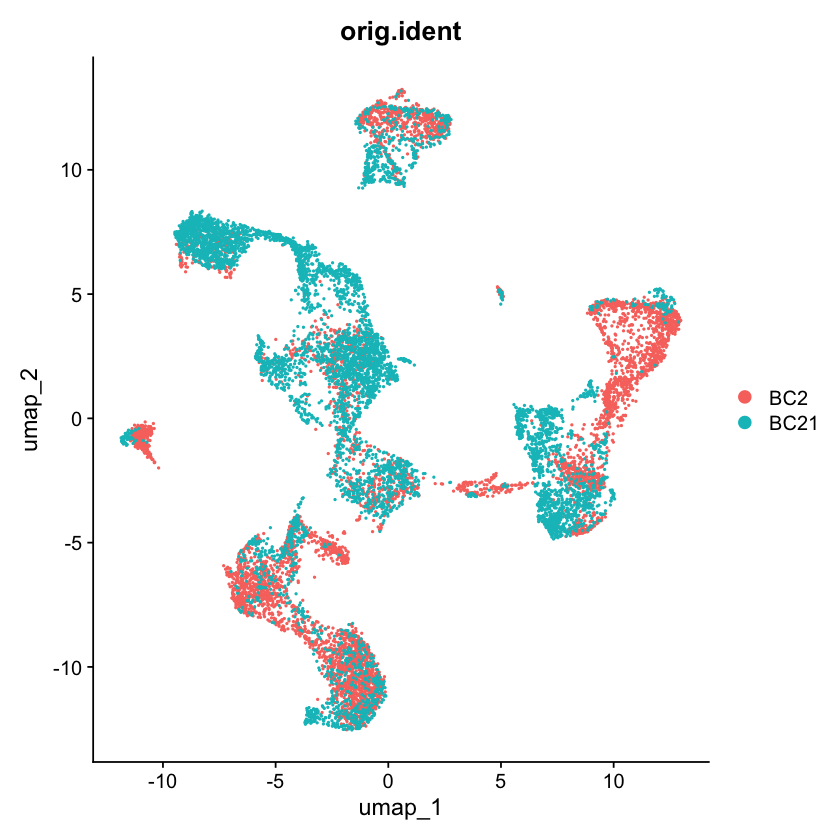

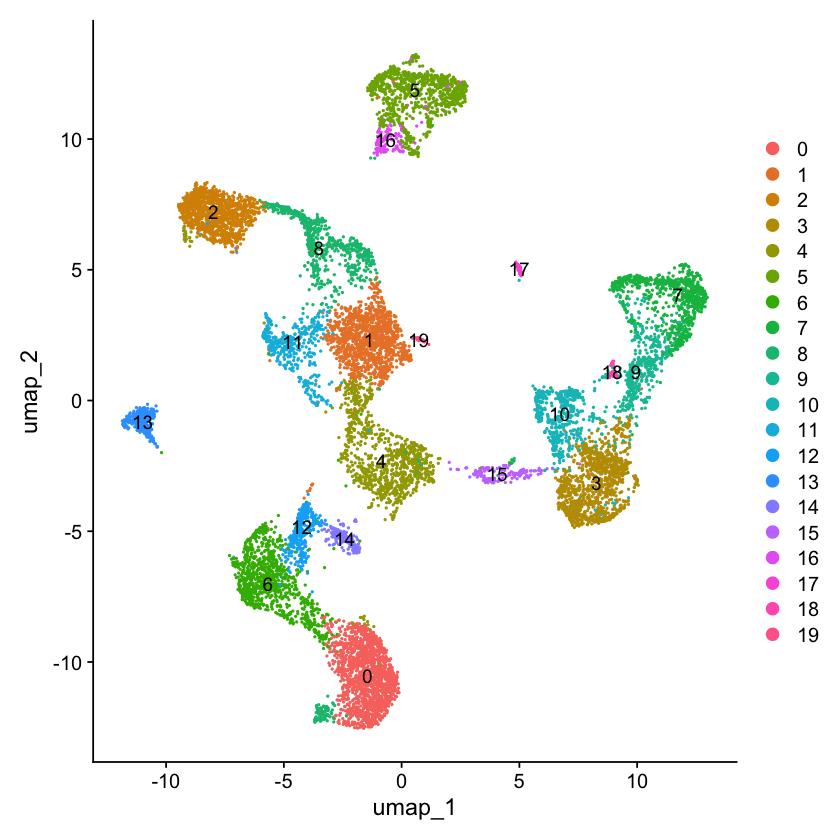

In [27]:
# t-SNE and Clustering

scRNA1 <- FindNeighbors(scRNA1, reduction = "pca", dims = 1:20)
scRNA1 <- FindClusters(scRNA1, resolution = 0.8)
scRNA1 <- RunUMAP(scRNA1, reduction = "pca", dims = 1:20)
colnames(scRNA1@meta.data)
scRNA1 <- RunTSNE(scRNA1, dims = 1:20)
colnames(scRNA1@meta.data)
DimPlot(scRNA1, reduction = "umap", group.by = "orig.ident")
DimPlot(scRNA1, reduction = "umap", label = TRUE)